In [1]:
%cd /home/songlin/workspace/projects/SIMPLE
%pwd

from dotenv import load_dotenv
load_dotenv()

/home/songlin/workspace/projects/SIMPLE


/home/songlin/workspace/projects/SIMPLE/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


True

In [2]:
!uv pip install matplotlib

Audited 1 package in 2ms


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from lerobot.datasets.lerobot_dataset import LeRobotDataset
# from lerobot.common.datasets.lerobot_dataset import LeRobotDataset

/home/songlin/workspace/projects/SIMPLE/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
sim_task = "G1WholebodyXMoveBendPick-v0"
level = "level-0"

root_dir = "/home/songlin/hfm/data/simple/learn/G1WholebodyXMoveBendPick-v0" #/{level}


In [5]:
# Load dataset
dataset = LeRobotDataset(repo_id=sim_task,root=root_dir) # , video_backend="pyav"
dataset.meta

LeRobotDatasetMetadata({
    Repository ID: 'G1WholebodyXMoveBendPick-v0',
    Total episodes: '100',
    Total frames: '23664',
    Features: '['observation.images.egocentric', 'observation.hand_joints', 'observation.arm_joints', 'observation.leg_joints', 'observation.prev_torso_rpy', 'observation.prev_height', 'states', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'next.done', 'task_index']',
})',

In [6]:
print("data fps:", dataset.meta.fps)

data fps: 50


In [7]:
frame = dataset[0]

In [8]:
from pprint import pprint

In [9]:

pprint(frame.keys())
# pprint(frame, width=120, sort_dicts=False)

dict_keys(['observation.images.egocentric', 'states', 'action', 'observation.hand_joints', 'observation.arm_joints', 'observation.leg_joints', 'observation.prev_torso_rpy', 'observation.prev_height', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'next.done', 'task'])


In [11]:
print(frame["task"])
print(frame["action"].shape)
print(frame["states"].shape)

xmove to the table and bend to pick up the cracker box
torch.Size([36])
torch.Size([32])


In [12]:
frame["states"][-4:]

tensor([-0.0084,  0.0727, -0.0054,  0.7400])

In [13]:
from PIL import Image

In [14]:
def pt_to_pil(x, normalized=True):
    s, b = (0.5, 0.5) if normalized else (1.0, 0.0)
    return Image.fromarray(
        (((x.float() * s + b).clamp(0, 1))*255.0).permute(1,2,0).cpu().numpy().astype(np.uint8)
    )

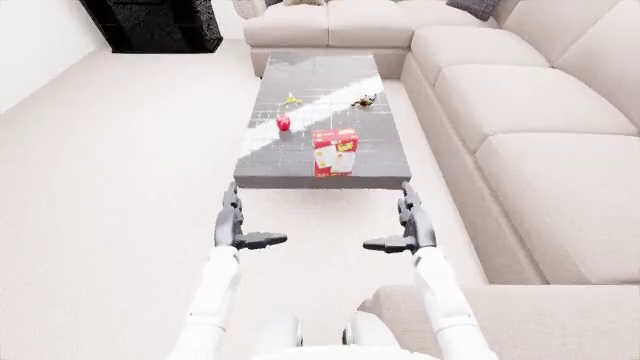

In [15]:
pt_to_pil(frame["observation.images.egocentric"], normalized=False)

In [16]:
eps_id = 0

In [17]:
from_idx = int(dataset.episode_data_index["from"][eps_id].item())
to_idx = int(dataset.episode_data_index["to"][eps_id].item())

In [18]:
print("number of frames:", to_idx - from_idx)

number of frames: 411


In [19]:
print(frame["states"].shape)
print(frame["action"].shape)
# print(frame["observation.amo_policy_dyaw"])

torch.Size([32])
torch.Size([36])


In [20]:
print(frame.keys())
print(frame["frame_index"])

dict_keys(['observation.images.egocentric', 'states', 'action', 'observation.hand_joints', 'observation.arm_joints', 'observation.leg_joints', 'observation.prev_torso_rpy', 'observation.prev_height', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'next.done', 'task'])
tensor(0)


## Use the same action format adopted by psi-0 
see `HE2LeRobotConverter.build_act`

```
...
return hand_joints + arm_joints + rpy + height + torso_vx + torso_vy + torso_vyaw + target_yaw # torso_dyaw # 36

```

In [21]:

joints_names=[
    "left_hip_pitch_joint", "left_hip_roll_joint", "left_hip_yaw_joint", "left_knee_joint", "left_ankle_pitch_joint", "left_ankle_roll_joint",
    "right_hip_pitch_joint", "right_hip_roll_joint", "right_hip_yaw_joint", "right_knee_joint", "right_ankle_pitch_joint", "right_ankle_roll_joint",
    "waist_yaw_joint", "waist_roll_joint", "waist_pitch_joint",
    "left_shoulder_pitch_joint", "left_shoulder_roll_joint", "left_shoulder_yaw_joint", "left_elbow_joint","left_wrist_roll_joint","left_wrist_pitch_joint","left_wrist_yaw_joint",
    "right_shoulder_pitch_joint", "right_shoulder_roll_joint", "right_shoulder_yaw_joint", "right_elbow_joint","right_wrist_roll_joint","right_wrist_pitch_joint","right_wrist_yaw_joint",
    "left_hand_thumb_0_joint", "left_hand_thumb_1_joint", "left_hand_thumb_2_joint", "left_hand_index_0_joint", "left_hand_index_1_joint", "left_hand_middle_0_joint", "left_hand_middle_1_joint",
    "right_hand_thumb_0_joint", "right_hand_thumb_1_joint", "right_hand_thumb_2_joint", "right_hand_index_0_joint", "right_hand_index_1_joint", "right_hand_middle_0_joint", "right_hand_middle_1_joint"
]


In [22]:
def from_psi0_upper_joints(psi0_action):
    return np.concatenate([
        psi0_action[14:28],
        psi0_action[0:3], # left thumb
        psi0_action[5:7], # left index
        psi0_action[3:5], # left middle
        psi0_action[7:14], # right hand
    ])

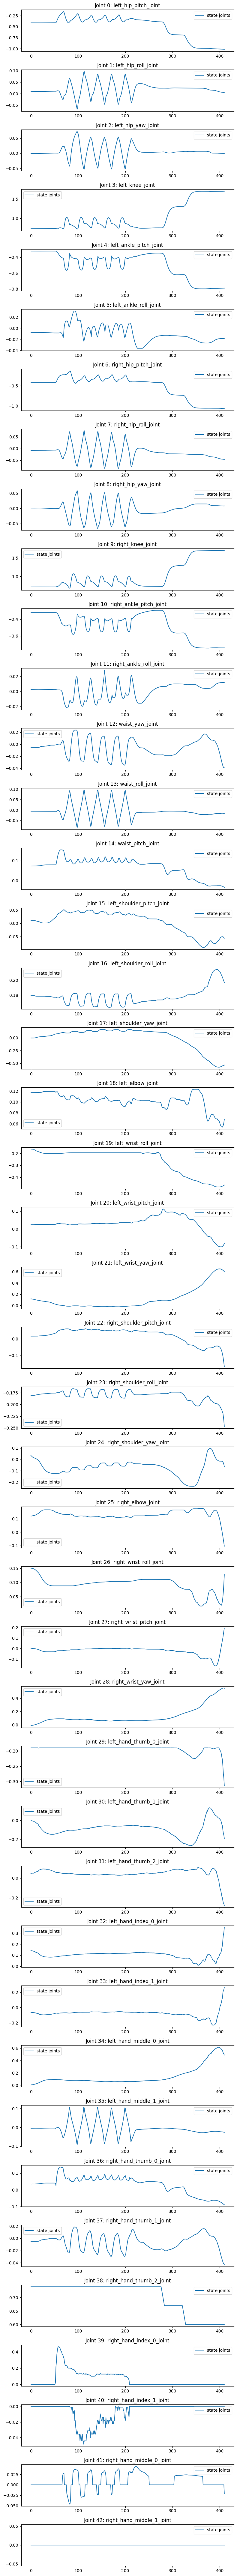

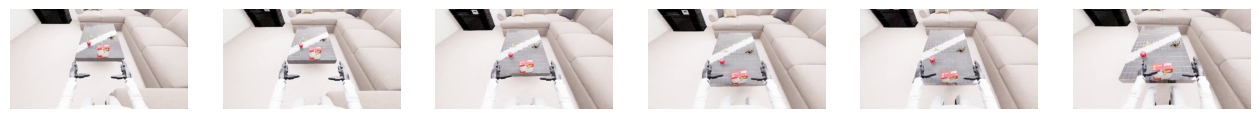

In [23]:
max_steps = to_idx - from_idx

state_joints_across_time = []
gt_action_joints_across_time = []
amo_inputs_across_time = []

# left_images = []
# side_images = []
# wrist_images = []
head_images = []

sample_images = 6
actions_36d = []
# states_31d = [] # hand + arm + torso 

# TODO torso_rpyh from previous frame? TBD ...

for step_count in range(from_idx, to_idx):
    data_point = dataset[step_count]
    
    # actions_36d.append(to_psi0_action_format(data_point))
    actions_36d.append(data_point["action"]) 
    # amo_inputs_across_time.append(data_point["observation.amo_policy_command"])
    # print(actions_36d[0].shape)
    # print(data_point.keys())
    
    state_joints = np.concatenate([
        data_point["observation.leg_joints"], # leg joints
        data_point["observation.arm_joints"], # torso rpy
        data_point["observation.hand_joints"], # arm joints
    ], axis=0)
    
    
    state_joints[-14:] = data_point["action"][-14:]
    
    # side_images = data_point["observation.rgb_side_left"]
    # wrist_images = data_point["observation.rgb_wrist"]
    # gt_action_joints = data_point["action.right_arm"][0]
   
    state_joints_across_time.append(state_joints)
    # gt_action_joints_across_time.append(gt_action_joints)

    # We can also get the image data
    if step_count % (max_steps // sample_images) == 0:
        # left_images.append(np.transpose(data_point["observation.rgb_front_stereo_left"], (1,2,0)))# 3,H,W
        # side_images.append(np.transpose(data_point["observation.rgb_side_left"], (1,2,0)))
        # wrist_images.append(np.transpose(data_point["observation.rgb_wrist"], (1,2,0)))
        head_images.append(np.transpose(data_point["observation.images.egocentric"], (1,2,0)))


# Size is (max_steps, num_joints == 7)
state_joints_across_time = np.array(state_joints_across_time)
# amo_inputs_across_time = np.array(amo_inputs_across_time)
# gt_action_joints_across_time = np.array(gt_action_joints_across_time)

# Plot the joint angles across time
fig, axes = plt.subplots(nrows=43, ncols=1, figsize=(8, 2*43))

for i, ax in enumerate(axes):
    ax.plot(state_joints_across_time[:, i], label="state joints")
    # ax.plot(gt_action_joints_across_time[:, i], label="gt action joints")
    ax.set_title(f"Joint {i}: {joints_names[i]}")
    ax.legend()

plt.tight_layout()
plt.show()

# Plot the images in a row
fig, axes = plt.subplots(nrows=1, ncols=sample_images, figsize=(16, 4))
for i, ax in enumerate(axes):
    ax.imshow(head_images[i]) # .numpy()
    ax.axis("off")

In [24]:
print(state_joints_across_time.shape)

(411, 43)


### actions: torso yaw/roll/pitch, base height

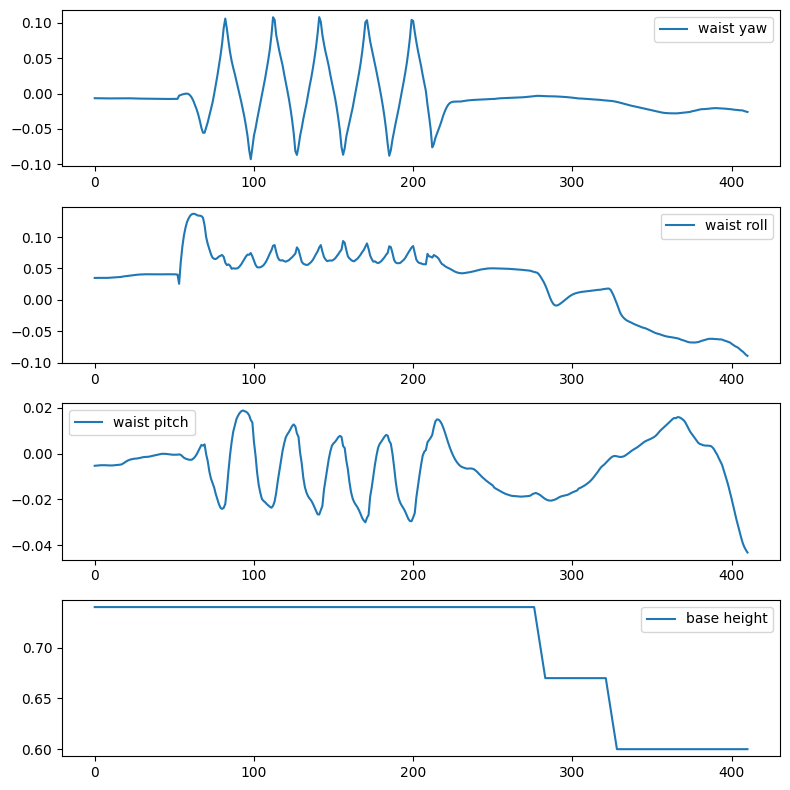

In [25]:
actions_36d = np.array(actions_36d, dtype=np.float32)
waist_yrp = actions_36d[:, 28:31] # waist yaw, roll, pitch
base_height = actions_36d[:, 31:32] # base height

# plot waist rpy and base height across time
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(8, 2*4))
axes[0].plot(waist_yrp[:, 0], label="waist yaw")
axes[1].plot(waist_yrp[:, 1], label="waist roll")
axes[2].plot(waist_yrp[:, 2], label="waist pitch")
axes[3].plot(base_height[:, 0], label="base height")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

# Inspect loco-motion

Vx, Vy, Vyaw, target_yaw

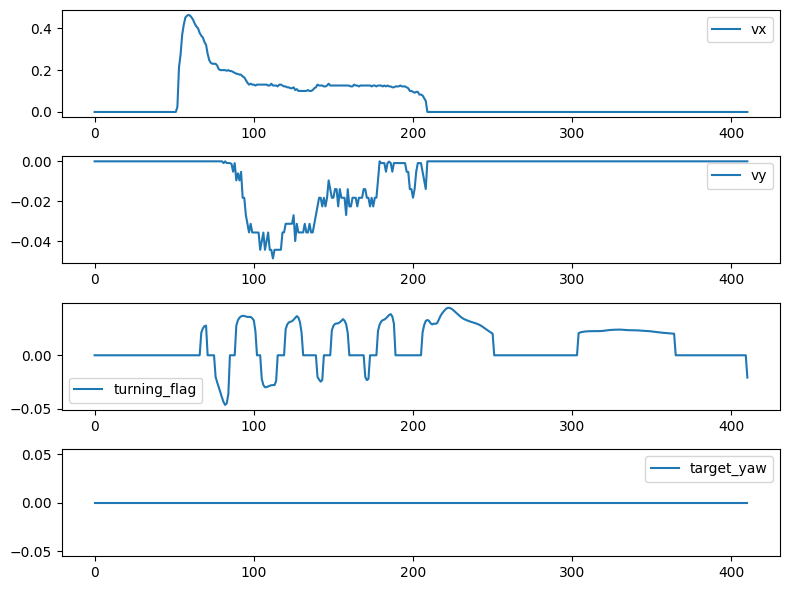

In [26]:
# amo_cmds = np.array(amo_inputs_across_time, dtype=np.float32)
# vxs = amo_cmds[:, 0]
# vys = amo_cmds[:, 1]
# target_yaws = amo_cmds[:, 3]

vxs = actions_36d[:, 32]
vys = actions_36d[:, 33]
turning_flags = actions_36d[:, 34]
target_yaws = actions_36d[:, 35]


# plot waist rpy and base height across time
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(8, 2*3))


axes[0].plot(vxs, label="vx")
axes[1].plot(vys, label="vy")
axes[2].plot(turning_flags, label="turning_flag")
axes[3].plot(target_yaws, label="target_yaw")
# axes[3].plot(base_height[:, 0], label="base height")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

